# Relax Challenge: User Adoption Analysis
Identifying factors that predict future user adoption.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Load data
engagement = pd.read_csv('takehome_user_engagement.csv', parse_dates=['time_stamp'])
users = pd.read_csv('takehome_users.csv', encoding='ISO-8859-1')

## 1. Defining Adoption
An 'adopted user' logged in on 3 separate days in at least one 7-day period.

In [28]:
def is_adopted(group):
    group = group.drop_duplicates('time_stamp').sort_values('time_stamp')
    if len(group) < 3: return False
    return any(group['time_stamp'].diff(periods=2) <= pd.Timedelta(days=7))

engagement['time_stamp'] = pd.to_datetime(engagement['time_stamp'])
adopted_map = engagement.groupby('user_id').apply(is_adopted)
users['adopted'] = users['object_id'].map(adopted_map).fillna(False).astype(int)

C:\Users\Irina Kim\AppData\Local\Temp\ipykernel_39984\1814237139.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  adopted_map = engagement.groupby('user_id').apply(is_adopted)
C:\Users\Irina Kim\AppData\Local\Temp\ipykernel_39984\1814237139.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  users['adopted'] = users['object_id'].map(adopted_map).fillna(False).astype(int)


## 2. Feature Engineering & Modeling

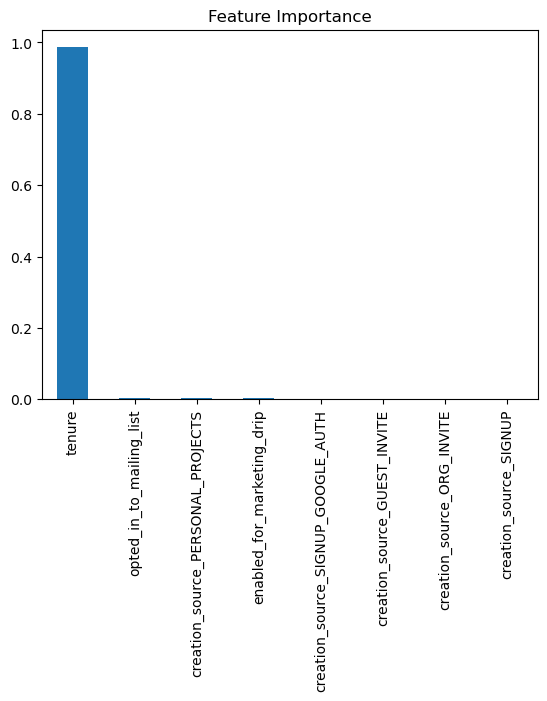

In [30]:
users['creation_time'] = pd.to_datetime(users['creation_time'])
users['last_session_creation_time'] = pd.to_datetime(users['last_session_creation_time'], unit='s')
users['tenure'] = (users['last_session_creation_time'] - users['creation_time']).dt.days.fillna(0).clip(lower=0)

features = pd.get_dummies(users[['creation_source', 'opted_in_to_mailing_list', 'enabled_for_marketing_drip', 'tenure']])
X_train, X_test, y_train, y_test = train_test_split(features, users['adopted'], test_size=0.2, random_state=42)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=features.columns).sort_values(ascending=False)
importances.plot(kind='bar', title='Feature Importance')
plt.show()